# 02 - ADS-B Trace Strategy and Quality Review

The default project path no longer builds a massive point-level `trajectories.parquet`. Instead, we use schedule-aware windows, downsample pings, and save compact flight-level vectors. This notebook explains and visualizes that strategy.

## 1. Setup

In [1]:
from pathlib import Path
import sys, json, subprocess
import pandas as pd
from IPython.display import display, Image, HTML


def resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root. Run this notebook from the repo or notebooks folder.')

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config
from src.pipeline_reporting import configure_pretty_logging, output_dir, save_dataset_inventory, save_dataframe, save_table_image, save_bar_chart

config = load_config(PROJECT_ROOT / 'configs' / 'config.yaml')
paths = config['paths']
processed_dir = PROJECT_ROOT / paths.get('processed_data_dir', 'data/processed')
raw_dir = PROJECT_ROOT / paths.get('raw_data_dir', 'data/raw')
outputs_dir = PROJECT_ROOT / 'outputs'
notebook_out = output_dir('02_trace_strategy', root=outputs_dir / 'notebook_reports')
log_file = configure_pretty_logging(PROJECT_ROOT / 'logs', '02_trace_strategy')
print('Project root:', PROJECT_ROOT)
print('Notebook output dir:', notebook_out)
print('Notebook log file:', log_file)

Project root: C:\Code\flight-disruption-prediction
Notebook output dir: C:\Code\flight-disruption-prediction\outputs\notebook_reports\02_trace_strategy
Notebook log file: C:\Code\flight-disruption-prediction\logs\02_trace_strategy_20260420_194356.log


## 2. Data Flow Diagram

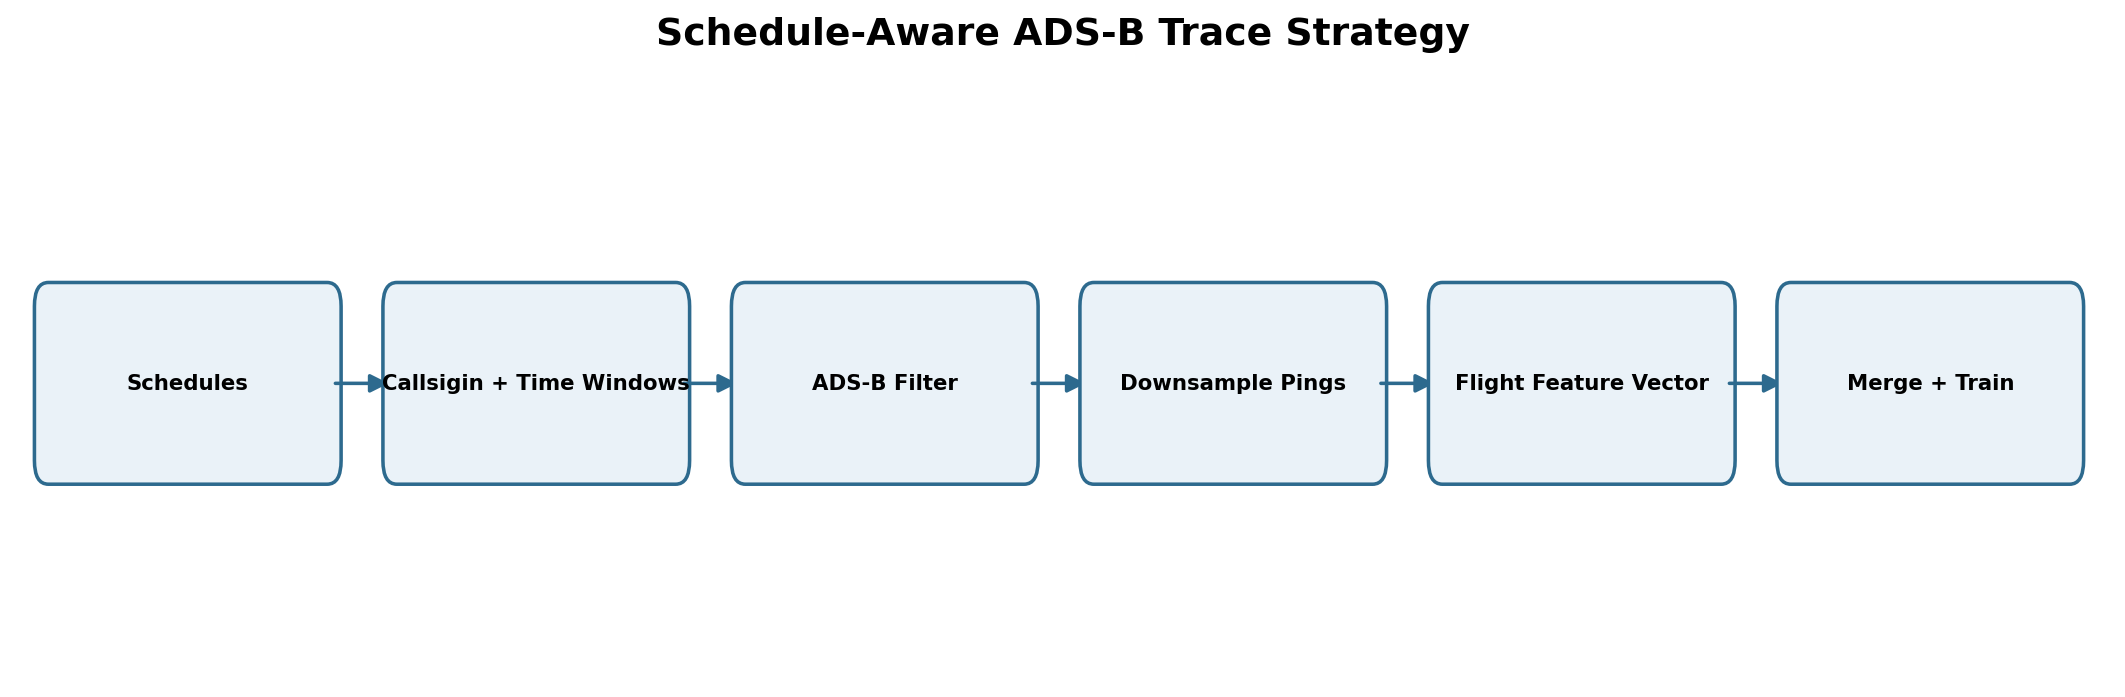

In [2]:
from src.pipeline_reporting import save_pipeline_flow_diagram
flow_path = save_pipeline_flow_diagram(
    ['Schedules', 'Callsigin + Time Windows', 'ADS-B Filter', 'Downsample Pings', 'Flight Feature Vector', 'Merge + Train'],
    'trace_strategy_flow',
    notebook_out,
    title='Schedule-Aware ADS-B Trace Strategy',
)
display(Image(filename=str(flow_path)))

## 3. Feature Quality Summary

Feature shape: (84916, 47)


,trajectory_id,icao24,callsign,timestamp,start_time_utc,end_time_utc,dep_anchor_confidence,arr_anchor_confidence,dep_anchor_is_partial,arr_anchor_is_partial,...,unstable_descent_flag,schedule_flight_key_hint,schedule_source_hint,candidate_scheduled_dep,candidate_scheduled_arr,candidate_origin,candidate_destination,raw_window_points,downsampled_points,feature_extraction_mode
0,FFT2130_202205020707_F9213020220502,a1ba0f,FFT2130,1.651477e+09,2022-05-02 07:36:00+00:00,2022-05-02 10:50:10+00:00,1.0,1.0,False,False,...,False,F92130_20220502,bts,2022-05-02 07:07:00+00:00,2022-05-02 11:07:00+00:00,KLAS,KDTW,1037,177,schedule_aware_direct
1,FFT2130_202205091400_F9213020220509,a3c900,FFT2130,1.652105e+09,2022-05-09 14:02:10+00:00,2022-05-09 17:13:40+00:00,1.0,1.0,False,False,...,False,F92130_20220509,bts,2022-05-09 14:00:00+00:00,2022-05-09 17:55:00+00:00,KLAS,KDTW,982,182,schedule_aware_direct
2,FFT2130_202205161400_F9213020220516,a3b414,FFT2130,1.652710e+09,2022-05-16 14:02:40+00:00,2022-05-16 17:27:20+00:00,1.0,1.0,False,False,...,False,F92130_20220516,bts,2022-05-16 14:00:00+00:00,2022-05-16 17:55:00+00:00,KLAS,KDTW,1086,196,schedule_aware_direct
3,FFT2130_202205231400_F9213020220523,a21f57,FFT2130,1.653318e+09,2022-05-23 14:52:30+00:00,2022-05-23 18:08:40+00:00,1.0,1.0,False,False,...,False,F92130_20220523,bts,2022-05-23 14:00:00+00:00,2022-05-23 17:55:00+00:00,KLAS,KDTW,1084,208,schedule_aware_direct
4,FFT2130_202205301450_F9213020220530,a4380f,FFT2130,1.653923e+09,2022-05-30 15:08:40+00:00,2022-05-30 18:15:30+00:00,1.0,1.0,False,False,...,False,F92130_20220530,bts,2022-05-30 14:50:00+00:00,2022-05-30 18:45:00+00:00,KLAS,KDTW,1106,188,schedule_aware_direct


,status,count
0,full_flight,40160
1,partial_end_missing,19296
2,partial_start_missing,17692
3,airborne_only,6688
4,ground_only,1080


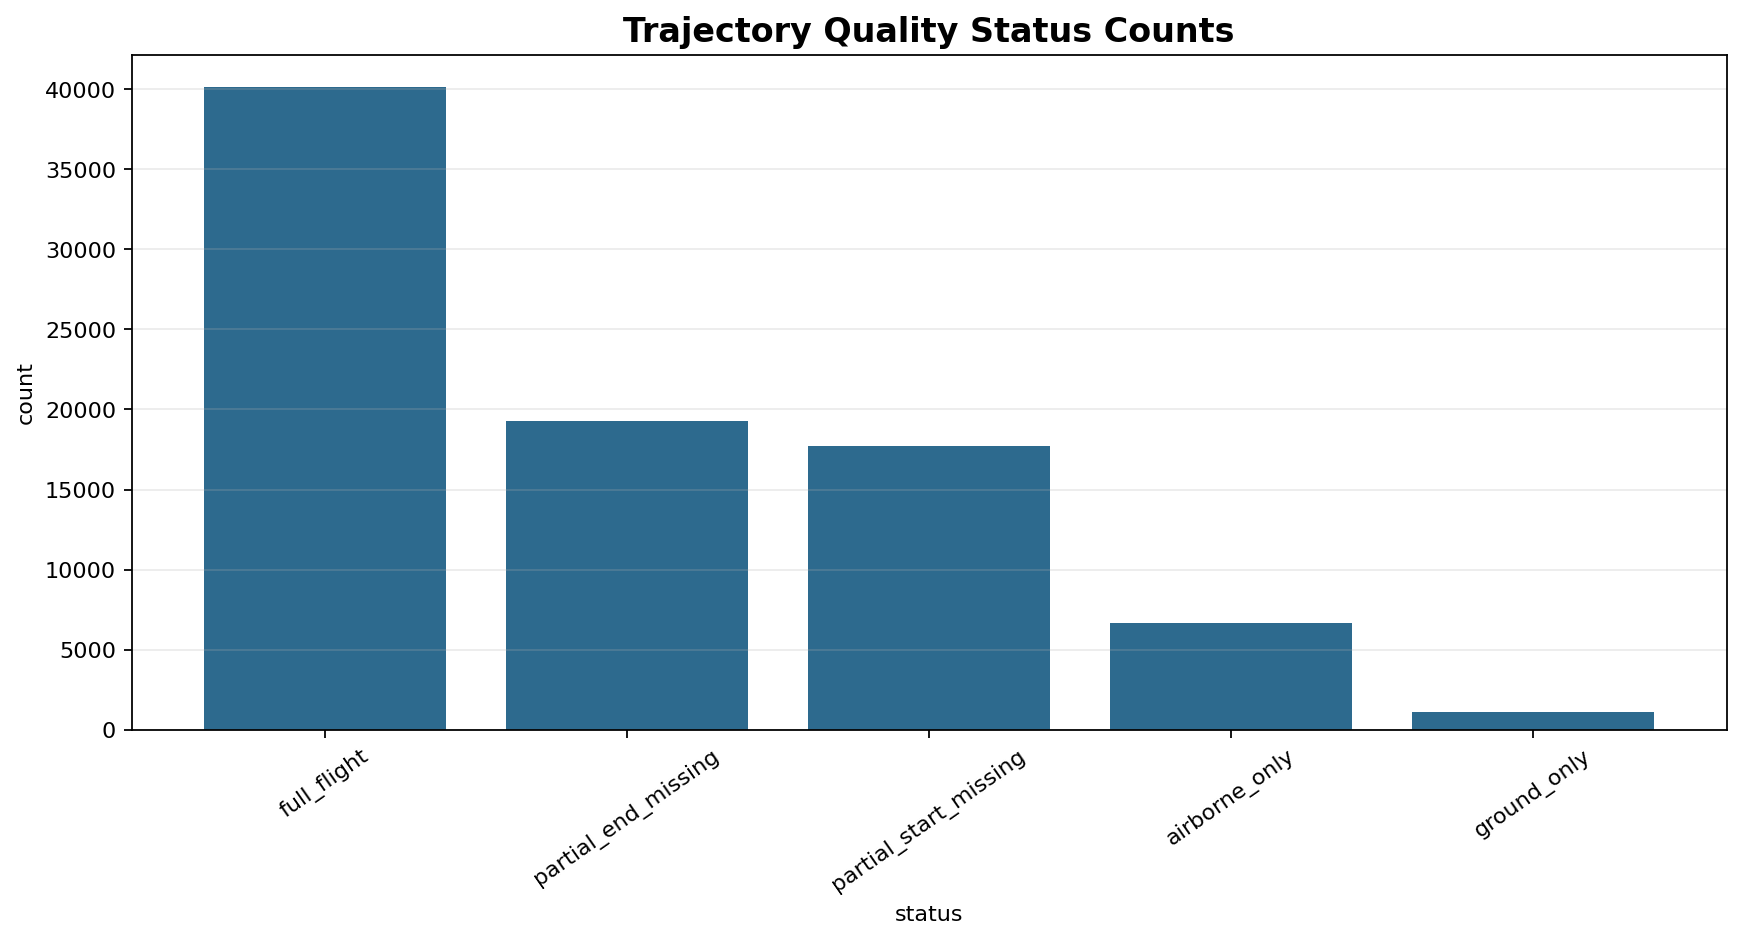

In [3]:
feature_path = processed_dir / paths.get('features_file', 'trajectory_features.parquet')
if not feature_path.exists():
    print('No trajectory feature file yet. Run notebook 03 or `python main.py --stage features --force`.')
else:
    df_features = pd.read_parquet(feature_path)
    print('Feature shape:', df_features.shape)
    display(df_features.head())
    if 'trajectory_quality_status' in df_features.columns:
        quality = df_features['trajectory_quality_status'].value_counts(dropna=False).rename_axis('status').reset_index(name='count')
        save_dataframe(quality, 'trajectory_quality_status', notebook_out)
        save_bar_chart(quality, 'status', 'count', 'trajectory_quality_status', notebook_out, title='Trajectory Quality Status Counts')
        display(quality)
        display(Image(filename=str(notebook_out / 'trajectory_quality_status.png')))

## 4. Coverage and Ping-Interval Diagnostics

,feature,count,mean,std,min,5%,25%,50%,75%,95%,max
0,num_points,84916.0,146.264826,66.735862,10.000000,63.000000,93.000000,132.000000,191.000000,278.00000,300.000000
1,raw_window_points,84916.0,587.490862,370.642231,10.000000,123.000000,317.000000,512.000000,776.000000,1339.00000,2567.000000
2,downsampled_points,84916.0,146.264826,66.735862,10.000000,63.000000,93.000000,132.000000,191.000000,278.00000,300.000000
3,route_coverage_fraction,84916.0,0.907290,0.168265,0.068108,0.528461,0.857143,1.000000,1.000000,1.00000,1.000000
4,middle_gap_count,84916.0,0.363665,0.632145,0.000000,0.000000,0.000000,0.000000,1.000000,2.00000,6.000000
5,max_inter_ping_seconds,84916.0,1134.821235,1817.909352,10.000000,10.000000,60.000000,230.000000,1280.000000,5290.00000,17780.000000
6,ping_interval_cv,84916.0,1.359461,1.780131,0.000000,0.000000,0.217083,0.481154,1.929727,4.75842,13.291927


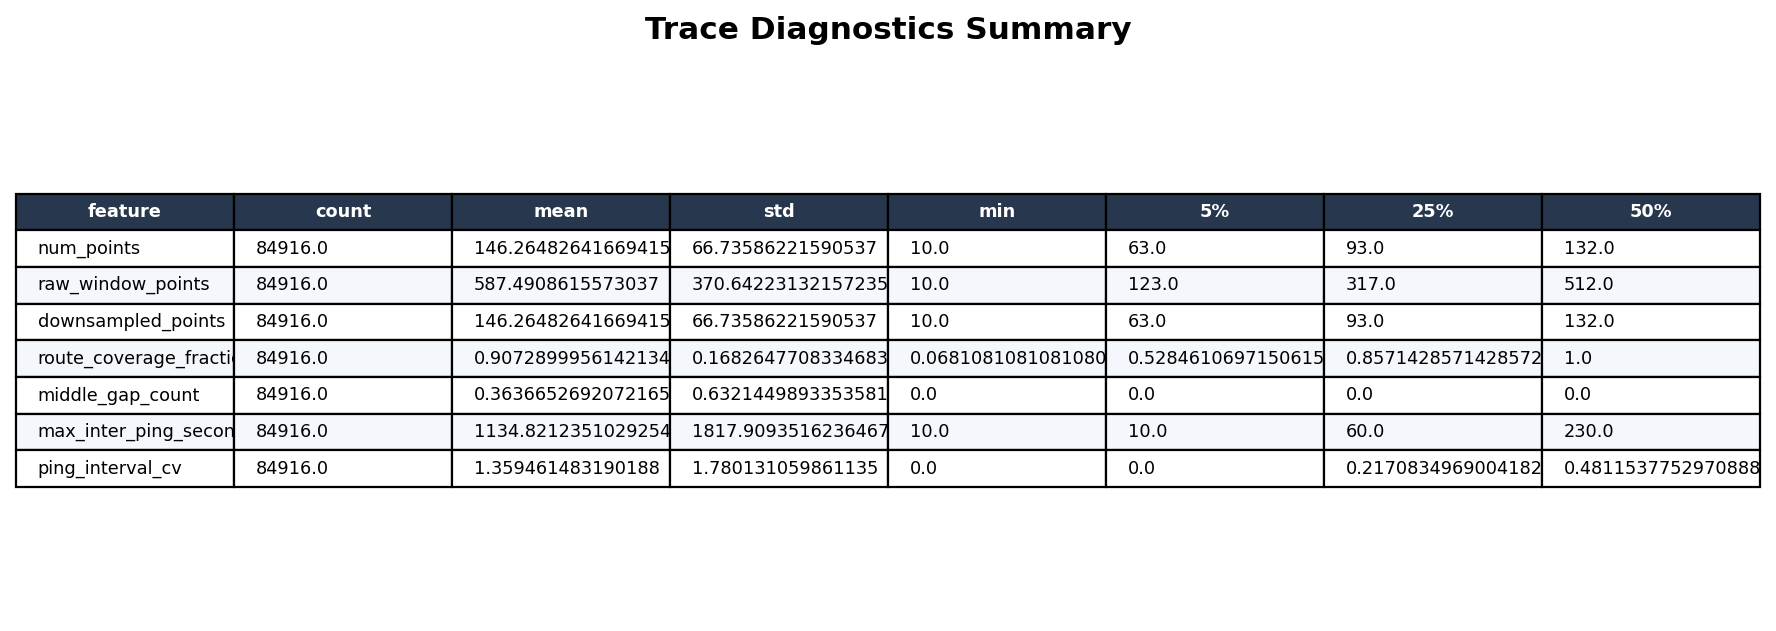

In [4]:
if feature_path.exists():
    df_features = pd.read_parquet(feature_path)
    diagnostic_cols = [c for c in ['num_points', 'raw_window_points', 'downsampled_points', 'route_coverage_fraction', 'middle_gap_count', 'max_inter_ping_seconds', 'ping_interval_cv'] if c in df_features.columns]
    if diagnostic_cols:
        summary = df_features[diagnostic_cols].describe(percentiles=[.05, .25, .5, .75, .95]).T.reset_index(names='feature')
        save_dataframe(summary, 'trace_diagnostics_summary', notebook_out)
        save_table_image(summary, 'trace_diagnostics_summary', notebook_out, title='Trace Diagnostics Summary', max_rows=40)
        display(summary)
        display(Image(filename=str(notebook_out / 'trace_diagnostics_summary.png')))

## Route Map and Altitude Preview

Uses `trajectory_sketches.parquet` to save and display one representative route map plus altitude profile. If sketches do not exist yet, rerun feature extraction first.


In [5]:
from IPython.display import IFrame
from src.trajectory_preview import generate_trajectory_preview

preview = generate_trajectory_preview(
    sketches_path=processed_dir / paths.get('trajectory_sketches_file', 'trajectory_sketches.parquet'),
    features_path=processed_dir / paths.get('features_file', 'trajectory_features.parquet'),
    out_dir=notebook_out / 'trajectory_preview',
)

display(pd.DataFrame([preview]))
if preview.get('status') == 'success':
    print('Trajectory:', preview['trajectory_id'])
    print('Map HTML:', preview['map_html'])
    print('Altitude PNG:', preview['altitude_png'])
    display(IFrame(src=preview['map_html'], width='100%', height=560))
    display(Image(filename=preview['altitude_png']))
else:
    print(preview.get('message'))


,status,message,sketches_path
0,missing_sketches,Trajectory sketches not found at C:\Code\fligh...,C:\Code\flight-disruption-prediction\data\proc...


Trajectory sketches not found at C:\Code\flight-disruption-prediction\data\processed\trajectory_sketches.parquet. Run `python main.py --stage features --force` first.


## Optional Legacy Full Reconstruction


In [6]:
RUN_LEGACY_FULL_RECONSTRUCTION = False

if RUN_LEGACY_FULL_RECONSTRUCTION:
    import main as pipeline_main
    from src.data_validator import DataValidator
    validator = DataValidator(mode=config.get('validation_mode', 'warn_only'), log_dir=PROJECT_ROOT / 'logs')
    pipeline_main.stage_features(config, validator, force=True)
else:
    print('Legacy full reconstruction skipped. Current feature mode:', config.get('features', {}).get('mode'))

Legacy full reconstruction skipped. Current feature mode: schedule_aware_direct
